In [2]:
import itertools
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import torch.distributions as D
import numpy as np
from numpy.random import default_rng
import pymc as pm
from scipy.stats import vonmises
from scipy.special import i0

from insilico_stimuli.stimuli import GaborSet, CenterSurround

seed = 42
rng = default_rng(seed=seed)
torch.manual_seed(seed=seed)
EPSILON = 1e-12
mpl.style.use("seaborn")
sns.set_palette("colorblind")
sns.set_context("paper")
sns.set_style("darkgrid")
mpl.style.use("seaborn")

/usr/local/lib/python3.8/dist-packages/pkg_resources/__init__.py:123: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/usr/lib/python3/dist-packages/requests/__init__.py:89: RequestsDependencyWarning: urllib3 (1.26.12) or chardet (3.0.4) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "


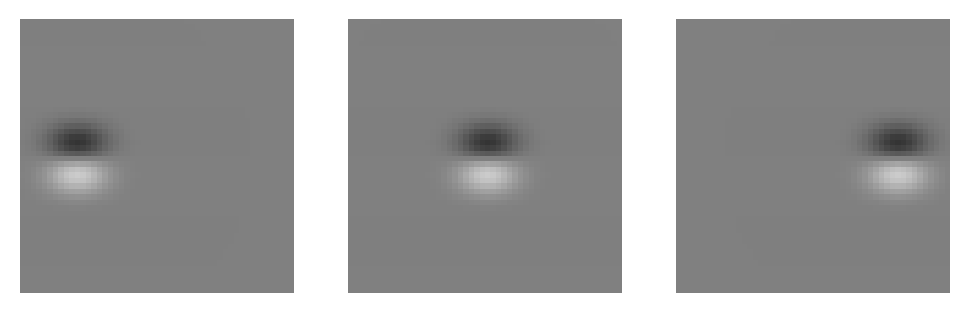

In [3]:
gabor_locations = [(10, 25), (25, 25), (40, 25)]
gabor_params = {
    "canvas_size": [50, 50],
    "sizes": [15],
    "spatial_frequencies": [1 / 20],
    "contrasts": [1.0],
    "grey_levels": [0.0],
    "eccentricities": [0.0],
    "locations": gabor_locations,
    "orientations": [np.pi / 2],
    "phases": [np.pi / 2],
    "relative_sf": False,
}

gabor_set = GaborSet(**gabor_params)
fig, axs = plt.subplots(nrows=1, ncols=3, dpi=200)
for idx, ax in enumerate(axs.ravel()):
    gabor = gabor_set.images()[idx]
    ax.imshow(gabor, cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")

(-0.5, 49.5, 49.5, -0.5)

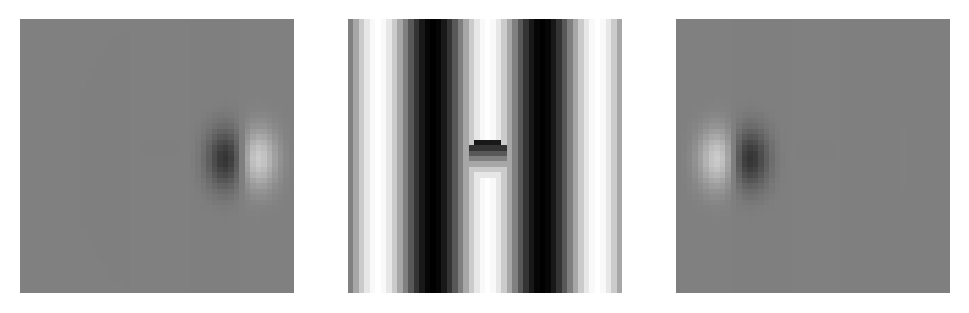

In [4]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": gabor_params["phases"],
    "phases_surround": [np.pi / 2 + 2 * np.pi * 1 / 20 * (25 - 10)],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [0.0],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15 / 4 / 50],
    "sizes_surround": [15 / 4 / 50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

center_cut = CenterSurround(**center_surround_params)

U, V = np.meshgrid(np.arange(50), np.arange(50))
XX = np.stack((U, V), axis=-1)
gauss_mask_right = np.exp(
    -np.sum((XX - np.array([40, 25])) ** 2, axis=-1) / (15 / 4) ** 2 / 2
)
gauss_mask_left = np.exp(
    -np.sum((XX - np.array([10, 25])) ** 2, axis=-1) / (15 / 4) ** 2 / 2
)

fig, axs = plt.subplots(nrows=1, ncols=3, dpi=200)
axs[0].imshow(center_cut.images()[0] * gauss_mask_right, cmap="gray", vmin=-1, vmax=1)
axs[0].axis("off")
axs[1].imshow(center_cut.images()[0], cmap="gray", vmin=-1, vmax=1)
axs[1].axis("off")
axs[2].imshow(center_cut.images()[0] * gauss_mask_left, cmap="gray", vmin=-1, vmax=1)
axs[2].axis("off")
# plt.imshow(center_cut.images()[0] * gauss_mask, cmap="gray", vmin=-1, vmax=1)
# plt.imshow(center_cut.images()[0], cmap="gray", vmin=-1, vmax=1)

plt.axis("off")

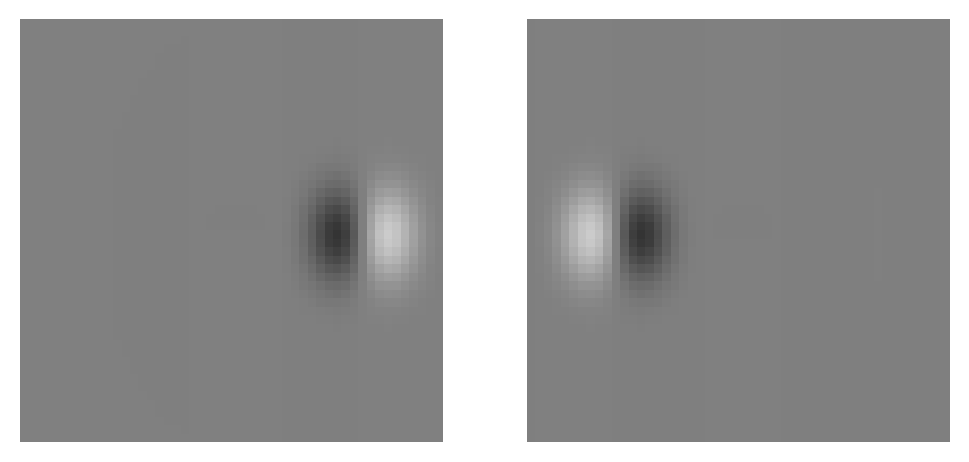

In [5]:
surround_right = center_cut.images()[0] * gauss_mask_right
surround_left = center_cut.images()[0] * gauss_mask_left
surround_filters = np.stack((surround_right, surround_left))
fig, axs = plt.subplots(ncols=2, dpi=200)
for idx, ax in enumerate(axs.ravel()):
    ax.imshow(surround_filters[idx], cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")

In [6]:
valid_gabors = np.concatenate((gabor_set.images(), surround_filters))

In [3]:
# orientations = np.array([np.pi/2, np.pi/2, np.pi/2, 0, 0])
# np.save("/src/project/computed/center_masked_surround_gabors_orientations.npy", orientations)

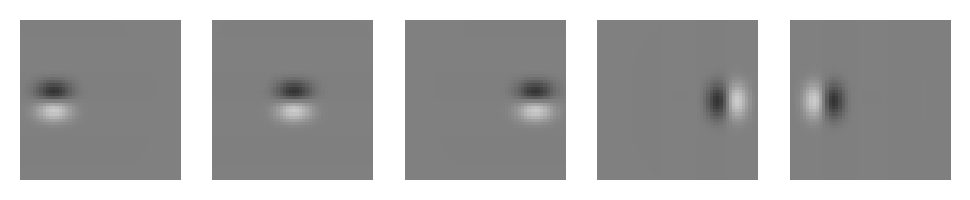

In [7]:
fig, axs = plt.subplots(nrows=1, ncols=5, dpi=200)
for idx, ax in enumerate(axs.ravel()):
    gabor = valid_gabors[idx]
    ax.imshow(gabor, cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")

(-0.5, 49.5, 49.5, -0.5)

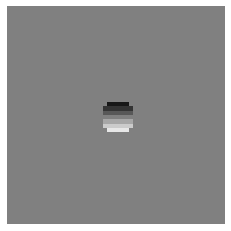

In [5]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": gabor_params["phases"],
    "phases_surround": [np.pi / 2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [0.0],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15 / 4 / 50],
    "sizes_surround": [15 / 4 / 50],
    "contrasts_center": [1.0],
    "contrasts_surround": [0],
}

center_cut = CenterSurround(**center_surround_params)

plt.imshow(center_cut.images()[0], cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

In [6]:
center_cut_stimulus = center_cut.images()[0]

(-0.5, 49.5, 49.5, -0.5)

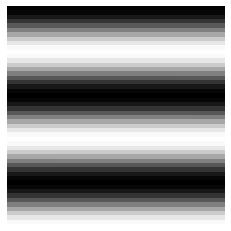

In [23]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": [1 / 20],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": [np.pi / 2],
    "phases_surround": [np.pi / 2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [np.pi / 2],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15 / 4 / 50],
    "sizes_surround": [15 / 4 / 50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

congruent_stimulus = CenterSurround(**center_surround_params).images()[0]
plt.imshow(congruent_stimulus, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

(-0.5, 49.5, 49.5, -0.5)

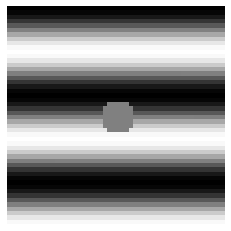

In [11]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": [1 / 20],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": [np.pi / 2],
    "phases_surround": [np.pi / 2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [np.pi / 2],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15 / 4 / 50],
    "sizes_surround": [15 / 4 / 50],
    "contrasts_center": [0],
    "contrasts_surround": [1.0],
}

congruent_no_center = CenterSurround(**center_surround_params).images()[0]
plt.imshow(congruent_no_center, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

(-0.5, 49.5, 49.5, -0.5)

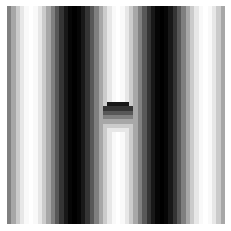

In [12]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": gabor_params["phases"],
    "phases_surround": [np.pi / 2 + 2 * np.pi * 1 / 20 * (25 - 10)],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [0.0],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15 / 4 / 50],
    "sizes_surround": [15 / 4 / 50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

incongruent_stimulus = CenterSurround(**center_surround_params).images()[0]
plt.imshow(incongruent_stimulus, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

(-0.5, 49.5, 49.5, -0.5)

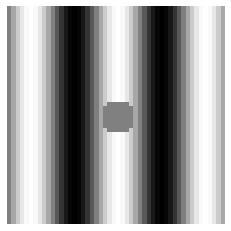

In [13]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": gabor_params["phases"],
    "phases_surround": [np.pi / 2 + 2 * np.pi * 1 / 20 * (25 - 10)],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [0.0],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15 / 4 / 50],
    "sizes_surround": [15 / 4 / 50],
    "contrasts_center": [0],
    "contrasts_surround": [1.0],
}

incongruent_no_center = CenterSurround(**center_surround_params).images()[0]
plt.imshow(incongruent_no_center, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

In [14]:
contrast_ratio = np.std(center_cut_stimulus) / np.std(congruent_stimulus)

(-0.5, 49.5, 49.5, -0.5)

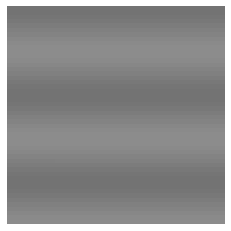

In [33]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": [1 / 20],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": [np.pi / 2],
    "phases_surround": [np.pi / 2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [np.pi / 2],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15 / 4 / 50],
    "sizes_surround": [15 / 4 / 50],
    "contrasts_center": [contrast_ratio],
    "contrasts_surround": [contrast_ratio],
}
congruent_contrast_matched = CenterSurround(**center_surround_params).images()[0]
plt.imshow(congruent_contrast_matched, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

(-0.5, 49.5, 49.5, -0.5)

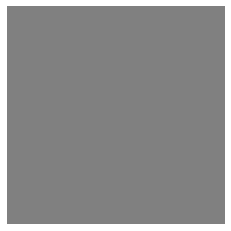

In [31]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": [1 / 20],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": [np.pi / 2],
    "phases_surround": [np.pi / 2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [np.pi / 2],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15 / 4 / 50],
    "sizes_surround": [15 / 4 / 50],
    "contrasts_center": [0],
    "contrasts_surround": [0],
}

blank = CenterSurround(**center_surround_params).images()[0]
plt.imshow(blank, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

In [18]:
np.std(congruent_contrast_matched)

0.07132698521772941

In [19]:
np.std(center_cut_stimulus)

0.07132698521772941

In [34]:
all_stimuli = np.array(
    [
        blank,
        center_cut_stimulus,
        incongruent_stimulus,
        incongruent_no_center,
        congruent_stimulus,
        congruent_no_center,
        congruent_contrast_matched,
    ]
)

IndexError: index 7 is out of bounds for axis 0 with size 7

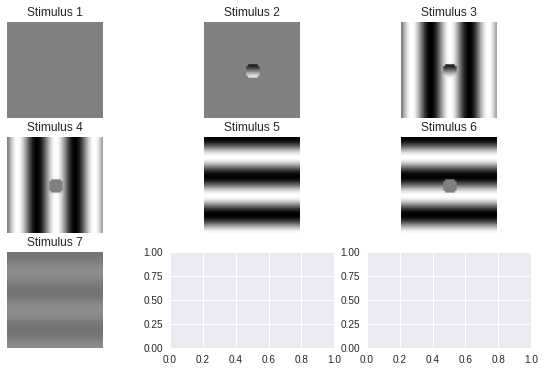

In [35]:
# plot all stimuli
fig, axes = plt.subplots(3, 3, figsize=(10, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(all_stimuli[i], cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")
    ax.set_title(f"Stimulus {i+1}")

In [22]:
# np.save("/src/project/computed/center_cut_congruent_incongruent.npy", stimuli)

In [36]:
# np.save("/src/project/computed/center_cut_congruent_incongruent_all.npy", all_stimuli)